In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_marketing_funnel_data.csv")

In [3]:
visitors = df["visited_website"].sum()
product_views = df["viewed_product"].sum()
cart_additions = df["added_to_cart"].sum()
checkout_starts = df["checkout_started"].sum()
purchases = df["purchase_completed"].sum()

print("Visitors:", visitors)
print("Product Views:", product_views)
print("Added to Cart:", cart_additions)
print("Checkout Started:", checkout_starts)
print("Purchases:", purchases)

Visitors: 120000
Product Views: 77870
Added to Cart: 27156
Checkout Started: 16234
Purchases: 8181


In [5]:
view_rate = (product_views / visitors) * 100
cart_rate = (cart_additions / product_views) * 100
checkout_rate = (checkout_starts / cart_additions) * 100
purchase_rate = (purchases / checkout_starts) * 100
overall_conversion = (purchases / visitors) * 100

print(f"Website → Product View Conversion: {view_rate:.2f}%")
print(f"Product View → Cart Conversion: {cart_rate:.2f}%")
print(f"Cart → Checkout Conversion: {checkout_rate:.2f}%")
print(f"Checkout → Purchase Conversion: {purchase_rate:.2f}%")
print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

Website → Product View Conversion: 64.89%
Product View → Cart Conversion: 34.87%
Cart → Checkout Conversion: 59.78%
Checkout → Purchase Conversion: 50.39%
Overall Conversion Rate: 6.82%


In [7]:
drop_view = 100 - view_rate
drop_cart = 100 - cart_rate
drop_checkout = 100 - checkout_rate
drop_purchase = 100 - purchase_rate

print(f"Drop-off after website visit: {drop_view:.2f}%")
print(f"Drop-off after product view: {drop_cart:.2f}%")
print(f"Drop-off after cart: {drop_checkout:.2f}%")
print(f"Drop-off after checkout: {drop_purchase:.2f}%")

Drop-off after website visit: 35.11%
Drop-off after product view: 65.13%
Drop-off after cart: 40.22%
Drop-off after checkout: 49.61%


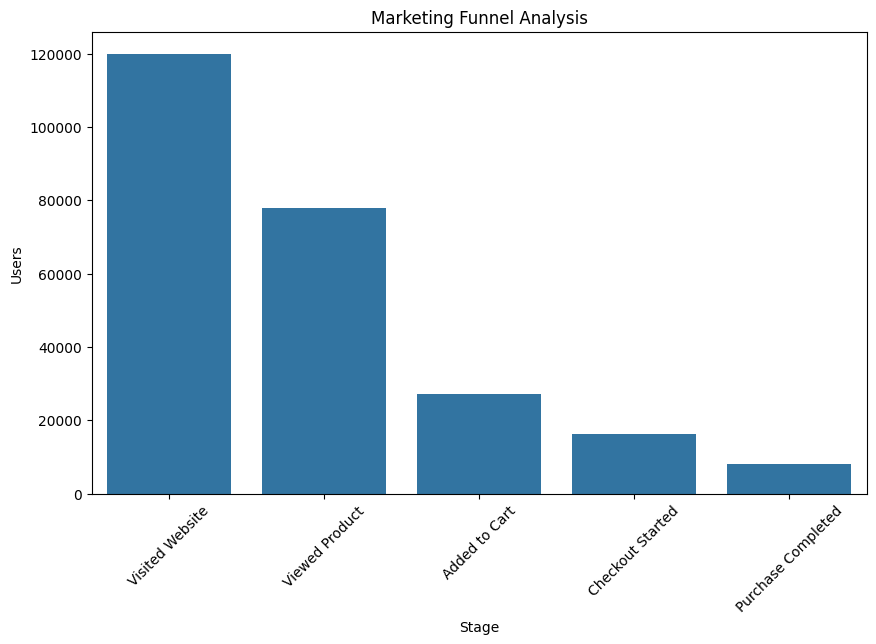

In [9]:
funnel_data = {
    "Stage": [
        "Visited Website",
        "Viewed Product",
        "Added to Cart",
        "Checkout Started",
        "Purchase Completed"
    ],
    "Users": [
        visitors,
        product_views,
        cart_additions,
        checkout_starts,
        purchases
    ]
}

funnel_df = pd.DataFrame(funnel_data)

plt.figure(figsize=(10,6))
sns.barplot(data=funnel_df, x="Stage", y="Users")
plt.title("Marketing Funnel Analysis")
plt.xticks(rotation=45)
plt.show()

In [10]:
funnel_df.to_csv("../reports/funnel_summary.csv", index=False)